# **Plotting a Pourbaix diagram the `MaterialsProject` API with `pyEQL`**

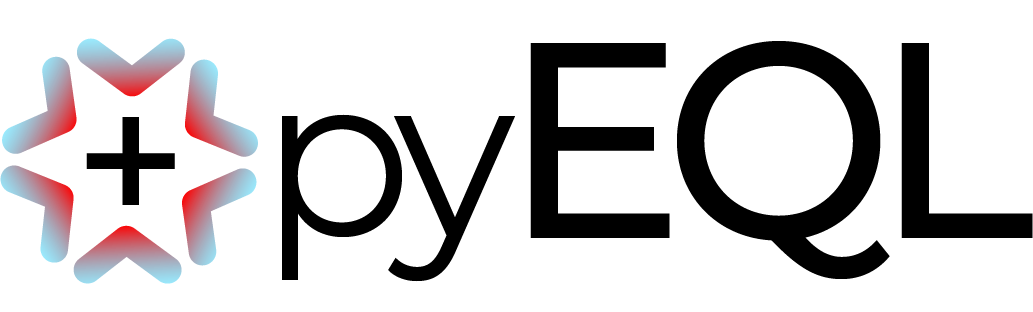

If you use this infrastructure, please consider citing the following work:

K. A. Persson, B. Waldwick, P. Lazic and G. Ceder, Phys. Rev. B, 2012, 85, 235438.

A. K. Singh, L. Zhou, A. Shinde, S. K. Suram, J. H. Montoya, D. Winston, J. M. Gregoire and K. A. Persson, Chem. Mater., 2017, DOI: acs.chemmater.7b03980.

S. X. Tay, A. Bhardwaj, R. Kingsbury, In Preparation, 2026.

The Materials Project REST interface includes functionality to construct pourbaix diagrams from computed entries. Note that the Pourbaix infrastructure is still undergoing revision, but now includes a simplified interface that enables MP and pymatgen users to fetch entries that have been processed according to the Materials Project Aqueous Compatibility scheme. Thus, users can reproduce web Pourbaix diagrams in two or three steps in pymatgen.

**NOTE** - make sure to paste your new API key below.

In [ ]:
MP_API_KEY = "API_KEY_HERE"

In [2]:
# Import necessary tools from pymatgen
# mp-api imports
from mp_api.client import MPRester

# pyEQL imports
from pyEQL.pourbaix.pourbaix_diagram import PourbaixDiagram, PourbaixPlotter, PourbaixEntry, MultiEntry, IonEntry

/home/st2591/.conda/envs/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Initialize the MP Rester
mpr = MPRester()

First, download all the relevant entries for **solid** phases in the chemical system of interest. Note that you must always include O and H in the chemical system here

In [4]:
# We include R2SCAN entries
entries = mpr.get_entries_in_chemsys(
    elements=["Na", "K", "Cl", "O", "H", "C", "Mg"], additional_criteria={"thermo_types": ["R2SCAN"]}
)

Retrieving ThermoDoc documents: 100%|██████████| 305/305 [00:00<00:00, 4809258.35it/s]


Next, process the solid entries using `MaterialsProjectAqueousCompatibility`, which makes adjustments to the energies to account for room temperature entropic effects and to guarantee that the formation energy of H2O is accurate.

In [5]:
# pyEQL imports
from pyEQL.pourbaix.compatibility import MaterialsProject2020Compatibility, MaterialsProjectAqueousCompatibility

In [6]:
aqcompat = MaterialsProjectAqueousCompatibility(solid_compat=None, universal_solid_shift_eV_per_atom=-0.062)
aqcompat.process_entries(entries)
# MaterialsProject2020Compatibility is omitted for solid entries

/home/st2591/.conda/envs/myenv/lib/python3.12/site-packages/monty/design_patterns.py:76: UserWarning: You did not provide the required O2 and H2O energies. MaterialsProjectAqueousCompatibility needs these energies in order to compute the appropriate energy adjustments. It will try to determine the values from ComputedEntry for O2 and H2O passed to process_entries, but will fail if these entries are not provided.
  orig_init(instance, *args, **kwargs)


[mp-1184808-r2SCAN ComputedStructureEntry - K8           (K)
 Energy (Uncorrected)     = -48.0383  eV (-6.0048  eV/atom)
 Correction               = -1.4536   eV (-0.1817  eV/atom)
 Energy (Final)           = -49.4918  eV (-6.1865  eV/atom)
 Energy Adjustments:
   Compound entropy at room temperature: -1.4536   eV (-0.1817  eV/atom)
 Parameters:
   potcar_spec            = [PotcarSpec(titel='PAW_PBE K_sv 06Sep2000', hash='826b5ed948c13aa5b3c5d792e26748af', summary_stats=None, @module='emmet.core.vasp.calculation', @class='PotcarSpec', @version=None)]
   run_type               = r2SCAN
 Data:
   oxide_type             = None
   aspherical             = True
   last_updated           = 2026-05-29 04:59:26.647782+00:00
   task_id                = aaaegygg
   material_id            = mp-1184808
   oxidation_states       = {Element K: 0.0}
   license                = BY-C
   run_type               = R2SCAN,
 mp-699482-r2SCAN ComputedStructureEntry - Na4 H40 C2 O26 (Na2H20CO13)
 Energy (Unco

In [7]:
# pymatgen imports
from pymatgen.analysis.phase_diagram import PhaseDiagram, PDPlotter, Composition, PDEntry, CompoundPhaseDiagram
from pymatgen.core.entries import ComputedEntry, ComputedStructureEntry, ConstantEnergyAdjustment
from pymatgen.core import Element, Composition, Structure

# pyEQL imports
from pyEQL.pourbaix.pourbaix_api import Pourbaix_api

The aqueous ion data for the Pourbaix diagram is constructed using the `Pourbaix_api`. This modified class leverages pyEQL, which interfaces with PHREEQC's aqueous speciation databases. The resulting aqueous complexes are then converted into ion entries, with free energy values obtained from the NBS database for Pourbaix Diagram construction.

In [8]:
pbx_api = Pourbaix_api(mpr=None, comp_dict={"Na+": 3.96, "K+": 0.604, "Cl-": 3.96, "Mg+2": 0.397})
ion_data = pbx_api.modified_get_ion_reference_data_for_chemsys(["Na", "K", "Cl", "O", "H", "Mg"])

/home/st2591/.conda/envs/myenv/lib/python3.12/functools.py:998: UserWarning: No Pauling electronegativity for He. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  val = self.func(instance)
/home/st2591/.conda/envs/myenv/lib/python3.12/functools.py:998: UserWarning: No Pauling electronegativity for Ne. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  val = self.func(instance)
/home/st2591/.conda/envs/myenv/lib/python3.12/functools.py:998: UserWarning: No Pauling electronegativity for Ar. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  val = self.func(instance)


The ComputedEntry we processed above contain electronic energies from DFT calculations. But to construct `PourbaixEntry`, we need their free energies of formation. In addition, we will need to exclude entries in the O, H, and O-H chemical system when we build the diagram. To determine the free energies, we use the `get_form_energy` of the compositional `PhaseDiagram` for solids.

In [9]:
pd = PhaseDiagram(entries)

free_energy_entries = [
    ComputedEntry(v.composition, pd.get_form_energy(v))
    for v in pd.stable_entries
    if v.composition.chemical_system not in ["O", "H", "H-O"]
]

The next step is to construct ion entries, which reference the free energies of aqueous species to the formation energies on the solid phase diagram

In [10]:
ion_entries = pbx_api.get_ion_entries(pd, ion_data)

Now, we create `PourbaixEntry` from both the solid ComputedEntry and the aqueous `IonEntry` objects. The resulting list of PourbaixEntry is equivalent to what is returned by `get_pourbaix_entries` in the first section

In [11]:
pbx_entries = [PourbaixEntry(e) for e in free_energy_entries]
pbx_entries.extend([PourbaixEntry(e) for e in ion_entries])

And finally, we create the `PourbaixDiagram` from the list of `PourbaixEntry` we have generated.

In [12]:
pbx = PourbaixDiagram(
    pbx_entries,
    comp_dict={"Na": 3.96, "K": 0.604, "Cl": 3.96, "Mg": 0.397},
    conc_dict={"Na": 3.96, "K": 0.604, "Cl": 3.96, "Mg": 0.397},
    filter_solids=False,
)

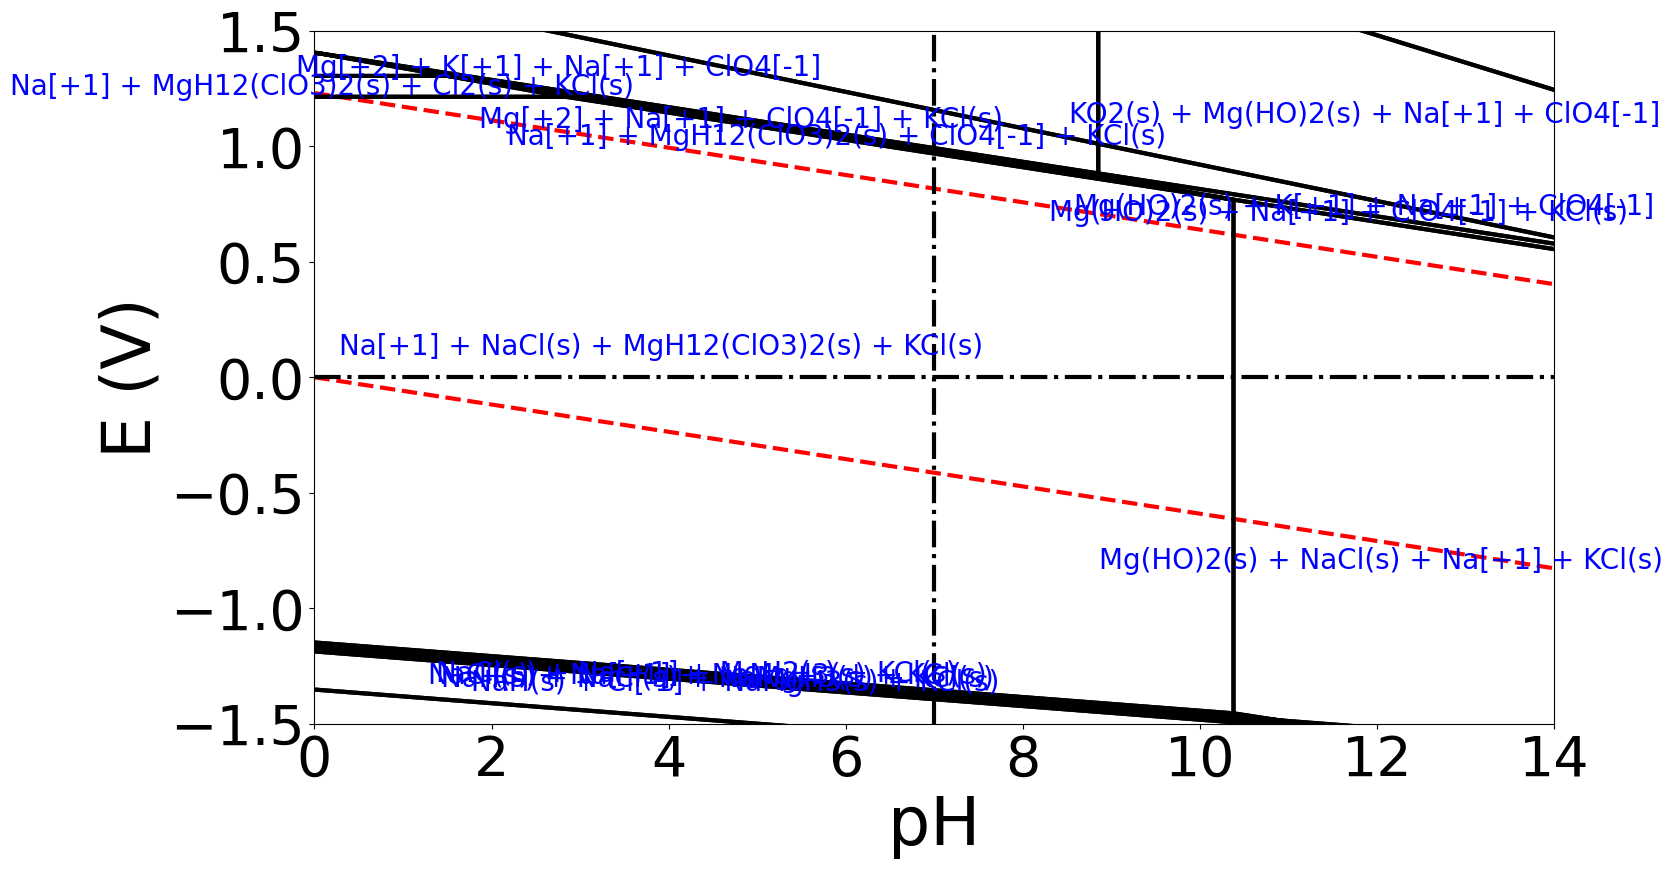

: 

In [ ]:
import matplotlib.pyplot as plt

ax = PourbaixPlotter(pbx).get_pourbaix_plot(limits=((0, 14), (-1.5, 1.5)))
plt.show()